In [82]:
import numpy as np
import matplotlib.pyplot as plt

In [83]:
sequence_length = 4
batch_size = 1
input_dim = 512
d_model = 512
x = np.random.rand(batch_size, sequence_length, input_dim)

In [ ]:
x.shape

torch.Size([1, 4, 512])

In [84]:
W_qkv = np.random.randn(d_model, d_model * 3) / np.sqrt(d_model)
b_qkv = np.zeros((d_model * 3,))
W_qkv.shape, b_qkv.shape

((512, 1536), (1536,))

In [85]:
qkv = np.matmul(x, W_qkv) + b_qkv

In [7]:
qkv.shape

torch.Size([1, 4, 1536])

Text(0.5, 1.0, 'QKV distribution')

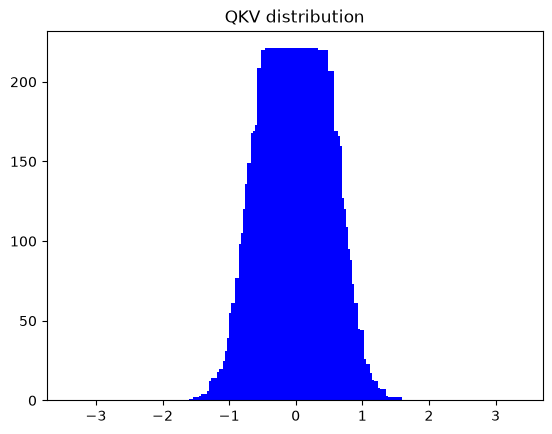

In [ ]:
bins = np.linspace(-3, 3, 201)
y_val, _ = np.histogram(qkv, bins=bins)
x_val = 0.5 * (bins[:-1] + bins[1:])
plt.bar(x_val, y_val, width=(bins[1] - bins[0]), align='center', color='blue')
plt.title('QKV distribution')

In [86]:
num_heads = 8
head_dim  = d_model // num_heads
qkv = qkv.reshape(batch_size, sequence_length, num_heads, 3 * head_dim)

In [10]:
qkv.shape

torch.Size([1, 4, 8, 192])

In [87]:
qkv = np.transpose(qkv, (0, 2, 1, 3))  # (batch_size, num_heads, sequence_length, 3 * head_dim)
qkv.shape

(1, 8, 4, 192)

In [88]:
q, k, v = np.split(qkv, 3, axis=-1)
q.shape, k.shape, v.shape

((1, 8, 4, 64), (1, 8, 4, 64), (1, 8, 4, 64))

$$
\text{self attention} = softmax\left(\frac{Q \cdot K^T}{\sqrt{d_k}} + M\right)
$$

$$
\text{new V} = \text{self attention} \cdot V
$$

In [89]:
d_k = q.shape[-1]
scaled = np.matmul(q, np.swapaxes(k, -2, -1)) / np.sqrt(d_k)
scaled.shape

(1, 8, 4, 4)

In [ ]:
np.swapaxes(k, -2, -1).shape

torch.Size([64, 4, 8, 1])

In [90]:
mask = np.full(scaled.shape, -np.inf)
mask = np.triu(mask, k=1)
mask[0][0]  # mask for one head

array([[  0., -inf, -inf, -inf],
       [  0.,   0., -inf, -inf],
       [  0.,   0.,   0., -inf],
       [  0.,   0.,   0.,   0.]])

In [20]:
(scaled + mask)[0][0]

tensor([[ 0.0635,    -inf,    -inf,    -inf],
        [ 0.0403,  0.0891,    -inf,    -inf],
        [ 0.0423,  0.0630,  0.0397,    -inf],
        [ 0.0206,  0.0929,  0.0084, -0.0325]], grad_fn=<SelectBackward0>)

In [91]:
scaled += mask

In [27]:
np.exp(0.0403) / (np.exp(0.0403) + np.exp(0.0891))

np.float64(0.48780242055422784)

In [92]:
exp_scaled = np.exp(scaled - np.max(scaled, axis=-1, keepdims=True))
attention = exp_scaled / np.sum(exp_scaled, axis=-1, keepdims=True)

In [25]:
attention.shape

torch.Size([1, 8, 4, 4])

In [26]:
attention[0][0]

tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.4878, 0.5122, 0.0000, 0.0000],
        [0.3313, 0.3383, 0.3304, 0.0000],
        [0.2493, 0.2680, 0.2463, 0.2364]], grad_fn=<SelectBackward0>)

In [93]:
values = np.matmul(attention, v)
values.shape

(1, 8, 4, 64)

In [94]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)

def scaled_dot_product_attention(q, k, v, mask=None) :
    d_k = q.shape[-1]
    scaled = np.matmul(q, np.swapaxes(k, -2, -1)) / np.sqrt(d_k)
    if mask is not None:
        scaled = scaled + mask
    attention = softmax(scaled, axis=-1)   # nhớ chỉ định axis=-1
    out = np.matmul(attention, v)
    return out, attention

In [95]:
values, attention = scaled_dot_product_attention(q, k, v, mask=mask)
values.shape, attention.shape

((1, 8, 4, 64), (1, 8, 4, 4))

In [71]:
attention[0][0]

array([[1.        , 0.        , 0.        , 0.        ],
       [0.48779687, 0.51220313, 0.        , 0.        ],
       [0.33130459, 0.33825798, 0.33043743, 0.        ],
       [0.24929753, 0.26798911, 0.24629479, 0.23641856]])

In [74]:
values.size, values.shape

(2048, (1, 8, 4, 64))

In [96]:
values = values.reshape(batch_size, sequence_length, num_heads * head_dim)
values.size, values.shape

(2048, (1, 4, 512))

In [97]:
W_o = np.random.randn(d_model, d_model) / np.sqrt(d_model)
b_o = np.zeros((d_model,))
W_o.shape, b_o.shape

((512, 512), (512,))

In [98]:
out = np.matmul(values, W_o) + b_o
out.shape, type(out)

((1, 4, 512), numpy.ndarray)

In [102]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x, axis=axis, keepdims=True)


def scaled_dot_product_attention(q, k, v, mask=None):
    d_k = q.shape[-1]
    scaled = np.matmul(q, np.swapaxes(k, -2, -1)) / np.sqrt(d_k)
    if mask is not None:
        scaled = scaled + mask
    attention = softmax(scaled, axis=-1)
    out = np.matmul(attention, v)
    return out, attention


class Parameter:
    def __init__(self, data):
        self.data = data
        self.grad = None


class Linear:
    def __init__(self, in_features, out_features):
        self.W = Parameter(np.random.randn(in_features, out_features) / np.sqrt(in_features))
        self.b = Parameter(np.zeros((out_features,)))

    def __call__(self, x):
        return np.matmul(x, self.W.data) + self.b.data


class MultiHeadAttention:
    def __init__(self, input_dim, d_model, num_heads):
        self.input_dim = input_dim
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.qkv_linear = Linear(input_dim, d_model * 3)
        self.out_linear = Linear(d_model, d_model)

    def __call__(self, x, mask=None):
        return self.forward(x, mask)

    def forward(self, x, mask=None):
        batch_size, sequence_length, _ = x.shape
        print(f"x.shape: {x.shape}")

        qkv = self.qkv_linear(x)
        print(f"qkv.shape: {qkv.shape}")

        qkv = qkv.reshape(batch_size, sequence_length, self.num_heads, 3 * self.head_dim)
        print(f"qkv.shape after reshape: {qkv.shape}")

        qkv = np.transpose(qkv, (0, 2, 1, 3))
        print(f"qkv.shape after transpose: {qkv.shape}")

        q, k, v = np.split(qkv, 3, axis=-1)
        print(f"q.shape: {q.shape}, k.shape: {k.shape}, v.shape: {v.shape}")

        values, attention = scaled_dot_product_attention(q, k, v, mask)
        print(f"values.shape: {values.shape}, attention.shape: {attention.shape}")

        values = values.reshape(batch_size, sequence_length, self.d_model)
        print(f"values.shape after reshape: {values.shape}")

        out = self.out_linear(values)
        print(f"out.shape: {out.shape}")
        return out

Input

In [105]:
input_dim = 1024
d_model = 512
num_heads = 8

batch_size = 30
sequence_length = 5
x = np.random.randn(batch_size, sequence_length, input_dim)
model = MultiHeadAttention(input_dim, d_model, num_heads)
out = model(x)
out.shape, type(out)

x.shape: (30, 5, 1024)
qkv.shape: (30, 5, 1536)
qkv.shape after reshape: (30, 5, 8, 192)
qkv.shape after transpose: (30, 8, 5, 192)
q.shape: (30, 8, 5, 64), k.shape: (30, 8, 5, 64), v.shape: (30, 8, 5, 64)
values.shape: (30, 8, 5, 64), attention.shape: (30, 8, 5, 5)
values.shape after reshape: (30, 5, 512)
out.shape: (30, 5, 512)


((30, 5, 512), numpy.ndarray)